# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Luca Bixade |        6129080      |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""

import numpy as np
import random
import sys
import time
from matplotlib import pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

random.seed(42)

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

TSP - Traveling Salesman Problem - is an optimization problem in Computer Science. Its definition is that, given a list of cities and the distances between all pairs of cities, we have to find the shortest possible route that visits all cities in the given route exactly once and returns to the starting point.

#### Question 2

1. Unlike the basic TSP, our given problem introduces the concept of mazes, walls preventing the travel between specific points.
2. Unlike the basic TSP, our given problem uses different movement, in a grid, instead of geometric distances.
3. Basic TSP starts with the distances already provided, but in this problem, the robot has to use a separate algorithm to find all the paths and distances.

#### Question 3

Since the problem is NP-hard, brute-forcing it is impossible in most cases. Using CI techniques, we can perform heuristic searches, which improve the brute force a lot, since instead of taking all the paths, we only take the most promising ones.

### 1.2 Genetic Algorithm

In [2]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    """
    def __init__(self, generations, pop_size):
        self.generations = generations
        self.pop_size = pop_size
    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        pass

First, we have to read the data. As the assignment mentioned, we read from optimal_tsp.

In [3]:
tsp_data = TSPData.read_from_file("../data/optimal_tsp")

distances = tsp_data.get_distances()       
start_dist = tsp_data.get_start_distances() 
end_dist = tsp_data.get_end_distances() 

print(len(tsp_data.get_distances()))
print(len(tsp_data.get_start_distances()))
print(len(tsp_data.get_end_distances()))

18
18
18


As it can be seen, we receive the correct number of products.

#### Question 4

In my implementation, the genes represent the products that are present in the store, stored using their IDs (the number of the product).
The chromosomes, which are sets of genes, thus, a possible solution or route, are encoded as a list, with each product being saved as its ID-1.

In [4]:
#added pop_size here so it can be tested
def generate_initial_population(num_products, pop_size):
    
    chromosomes = []
    base_route = list(range(num_products))
    
    for _ in range(pop_size):
        random_route = base_route.copy()
        random.shuffle(random_route)
        chromosomes.append(random_route)
        
    return chromosomes

num_products = len(tsp_data.get_start_distances()) 

population = generate_initial_population(num_products, 3)

print(population[0])
print(population[1])
print(population[2])

[13, 12, 4, 9, 5, 7, 16, 6, 10, 15, 1, 11, 2, 14, 17, 8, 0, 3]
[11, 14, 10, 8, 15, 1, 12, 5, 16, 2, 0, 4, 9, 7, 3, 13, 6, 17]
[14, 17, 6, 2, 15, 10, 16, 1, 8, 7, 0, 4, 9, 5, 13, 11, 3, 12]


#### Question 5

For the fitness function, i have chosen to use the inverse distance. 1e-6 was added to it to prevent the stuation of 0 distance, which would imply a division by 0. I have made this decision because, in TSP, we need the smallest distance, and maximize fitness. This means that we flip the way in which distances are perceived, now being direct proportional to fitness, which is more natural.

In [5]:
def calculate_route_distance(chromosome, start_dist, distances, end_dist):
    total_distance = 0.0
    
    first_product = chromosome[0]
    total_distance += start_dist[first_product]
    
    for i in range(len(chromosome) - 1):
        current_product = chromosome[i]
        next_product = chromosome[i+1]
        total_distance += distances[current_product][next_product]
        
    last_product = chromosome[-1]
    total_distance += end_dist[last_product]
    
    return total_distance

def calculate_fitness(distance):
    return 1.0 / (float(distance) + 1e-6)

sample = population[0]
distance = calculate_route_distance(sample, start_dist, distances, end_dist)
fitness = calculate_fitness(distance)

print(f"Route: {sample}")
print(f"Total Distance: {distance}")
print(f"Fitness Score: {fitness}")

Route: [13, 12, 4, 9, 5, 7, 16, 6, 10, 15, 1, 11, 2, 14, 17, 8, 0, 3]
Total Distance: 5655.0
Fitness Score: 0.00017683465956200978


#### Question 6

For the parent selection, i have chosen to use a tournament select, which ensures that the best performer is always selected from a specific number of individuals in the current population, without guaranteeing that it is the absolute best. How it works exactly is that it picks a small subset of individuals, compares their fitness scores, so the inverse of their distances, and takes the highest score(lowest distance).

In [6]:
def tournament_selection(population, fitness_scores, k=3):
    selected_indices = random.sample(range(len(population)), k)
    
    best_index = selected_indices[0]
    best_fitness = fitness_scores[best_index]
    
    for idx in selected_indices:
        if fitness_scores[idx] > best_fitness:
            best_fitness = fitness_scores[idx]
            best_index = idx
            
    return population[best_index]

#### Question 7

For genetic operations, I have chosen to implement a crossover and a mutation swap. For the crossover, we are doing a union of randomly selected subsets of the parents. This is done to, hopefully, get a better offspring. For the mutation swap, we are randomly swapping two genes inside a chromosome, to have diversity. This has also helped against getting stuck in a local minima.

In [7]:
def order_crossover(parent1, parent2):

    size = len(parent1)
    
    start, end = sorted(random.sample(range(size), 2))
    
    child = []

    for i in range(size):
        child.append(-1)

    for i in range(start, end + 1):
        child[i] = parent1[i]
    
    p2_idx= 0
    for i in range(size):
        if child[i] == -1:
            while parent2[p2_idx] in child:
                p2_idx += 1
                
            child[i] = parent2[p2_idx]
            
    return child

In [8]:
def swap(x, y):
    return y, x

In [9]:
def swap_mutation(chromosome, mutation_rate=0.1):
    mutated = chromosome.copy()
    
    if random.random() < mutation_rate:
        idx1, idx2 = random.sample(range(len(mutated)), 2)
        mutated[idx1], mutated[idx2] = swap(mutated[idx1], mutated[idx2])
        
    return mutated

#### Question 8

To avoid getting stuck in a local minima, we have implemented the genetic operation mentioned earlier. Using mutation swap, we ensure that there is still some variance in our chromosomes by slightly altering them (swapping two random genes),  which forces the robot to explore new paths.

#### Question 9

Elitism represents the action of copying the best invidual(s) from the current generation directly into the next one, without performing any changes on them. We have applied it, as we believe this is necessary in our code, because we are already minimising the risk of being stuck in a local minima, and not having it would make our algorithm truly random, which might, in many situations, give us bad final results, by removing the best route.

## Full algorithm:

In [10]:
class GeneticAlgorithm:

    def __init__(self, generations, pop_size, mutation_rate=0.1, use_elitism=True):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.use_elitism = use_elitism

    def generate_initial_population(self, num_products):
    
        chromosomes = []
        base_route = list(range(num_products))
    
        for _ in range(self.pop_size):
            random_route = base_route.copy()
            random.shuffle(random_route)
            chromosomes.append(random_route)
        
        return chromosomes

    def calculate_route_distance(self, chromosome, start_dist, distances, end_dist):
        total_distance = 0.0
    
        first_product = chromosome[0]
        total_distance += start_dist[first_product]
    
        for i in range(len(chromosome) - 1):
            current_product = chromosome[i]
            next_product = chromosome[i+1]
            total_distance += distances[current_product][next_product]
        
        last_product = chromosome[-1]
        total_distance += end_dist[last_product]
    
        return total_distance

    def calculate_fitness(self, distance):
        return 1.0 / (float(distance) + 1e-6)

    def tournament_selection(self, population, fitness_scores, k=3):
        selected_indices = random.sample(range(len(population)), k)
    
        best_index = selected_indices[0]
        best_fitness = fitness_scores[best_index]
    
        for idx in selected_indices:
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_index = idx
            
        return population[best_index]

    def order_crossover(self, parent1, parent2):

        size = len(parent1)
    
        start, end = sorted(random.sample(range(size), 2))
    
        child = []

        for i in range(size):
            child.append(-1)

        for i in range(start, end + 1):
            child[i] = parent1[i]
    
        p2_idx= 0
        for i in range(size):
            if child[i] == -1:
                while parent2[p2_idx] in child:
                    p2_idx += 1
                
                child[i] = parent2[p2_idx]
            
        return child

    def swap(self, x, y):
        return y, x

    def swap_mutation(self, chromosome, mutation_rate=0.1):
        mutated = chromosome.copy()
    
        if random.random() < mutation_rate:
            idx1, idx2 = random.sample(range(len(mutated)), 2)
            mutated[idx1], mutated[idx2] = self.swap(mutated[idx1], mutated[idx2])
        
        return mutated
    
    def solve_tsp(self, tsp_data):
        
        distances = tsp_data.get_distances()
        start_dist = tsp_data.get_start_distances()
        end_dist = tsp_data.get_end_distances()
        num_products = len(start_dist)
        
        chromosomes = self.generate_initial_population(num_products)
        best_overall_route = None
        best_overall_distance = float('inf')
        
        for gen in range(self.generations):
            fitness_scores = []
            
            for chromoz in chromosomes:
                dist = self.calculate_route_distance(chromoz, start_dist, distances, end_dist)
                fitness = self.calculate_fitness(dist)
                fitness_scores.append(fitness)
                
                if dist < best_overall_distance:
                    best_overall_distance = dist
                    best_overall_route = chromoz
            
            new_population = []
            
            #Elitism
            if self.use_elitism:
                best_idx = fitness_scores.index(max(fitness_scores))
                new_population.append(chromosomes[best_idx].copy())
                
            while len(new_population) < self.pop_size:
                p1 = self.tournament_selection(chromosomes, fitness_scores)
                p2 = self.tournament_selection(chromosomes, fitness_scores)
                
                child = self.order_crossover(p1, p2)
                child = self.swap_mutation(child)
                
                new_population.append(child)
                
            chromosomes = new_population
            
        return best_overall_route

## Test with 1000 runs to ensure that we get the optimal route, and we are not stuck in a local minima (elitism set to true - to get our final value)

In [11]:
pop_size = 5  # very small to have a small time, and also to provide clear information about the effect of elitism.
generations = 200    
read_from_file = "./../data/optimal_tsp"
k = 1000 # number of runs

tsp_data = TSPData.read_from_file(read_from_file)

distances = tsp_data.get_distances()
start_dist = tsp_data.get_start_distances()
end_dist = tsp_data.get_end_distances()

final_route = None
final_distance = float('inf')

for i in range(k):
    ga = GeneticAlgorithm(generations, pop_size, mutation_rate=0.1, use_elitism=True)
    
    current_route = ga.solve_tsp(tsp_data)
    current_distance = ga.calculate_route_distance(current_route, start_dist, distances, end_dist)
    
    if current_distance < final_distance:
        final_distance = current_distance
        final_route = current_route
        print(f"NEW BEST ON RUN {i + 1}| Distance: {final_distance}")
print("")
print(f"Best distance: {final_distance}")
print(f"It's sequence: {final_route}")

NEW BEST ON RUN 1| Distance: 3081.0
NEW BEST ON RUN 3| Distance: 2221.0
NEW BEST ON RUN 71| Distance: 2167.0
NEW BEST ON RUN 73| Distance: 1987.0
NEW BEST ON RUN 94| Distance: 1841.0
NEW BEST ON RUN 328| Distance: 1805.0
NEW BEST ON RUN 580| Distance: 1787.0
NEW BEST ON RUN 583| Distance: 1767.0
NEW BEST ON RUN 741| Distance: 1399.0

Best distance: 1399.0
It's sequence: [1, 0, 6, 4, 13, 15, 3, 8, 14, 9, 17, 7, 11, 12, 5, 10, 2, 16]


## Test with 1000 runs to ensure that we get the optimal route, and we are not stuck in a local minima (elitism set to false, to confirm that we are not stuck in a local minima (by getting a smaller value than with elitism set to true))

In [12]:
class GeneticAlgorithm:

    def __init__(self, generations, pop_size, mutation_rate=0.1, use_elitism=False):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.use_elitism = use_elitism

    def generate_initial_population(self, num_products):
    
        chromosomes = []
        base_route = list(range(num_products))
    
        for _ in range(self.pop_size):
            random_route = base_route.copy()
            random.shuffle(random_route)
            chromosomes.append(random_route)
        
        return chromosomes

    def calculate_route_distance(self, chromosome, start_dist, distances, end_dist):
        total_distance = 0.0
    
        first_product = chromosome[0]
        total_distance += start_dist[first_product]
    
        for i in range(len(chromosome) - 1):
            current_product = chromosome[i]
            next_product = chromosome[i+1]
            total_distance += distances[current_product][next_product]
        
        last_product = chromosome[-1]
        total_distance += end_dist[last_product]
    
        return total_distance

    def calculate_fitness(self, distance):
        return 1.0 / (float(distance) + 1e-6)

    def tournament_selection(self, population, fitness_scores, k=3):
        selected_indices = random.sample(range(len(population)), k)
    
        best_index = selected_indices[0]
        best_fitness = fitness_scores[best_index]
    
        for idx in selected_indices:
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_index = idx
            
        return population[best_index]

    def order_crossover(self, parent1, parent2):

        size = len(parent1)
    
        start, end = sorted(random.sample(range(size), 2))
    
        child = []

        for i in range(size):
            child.append(-1)

        for i in range(start, end + 1):
            child[i] = parent1[i]
    
        p2_idx= 0
        for i in range(size):
            if child[i] == -1:
                while parent2[p2_idx] in child:
                    p2_idx += 1
                
                child[i] = parent2[p2_idx]
            
        return child

    def swap(self, x, y):
        return y, x

    def swap_mutation(self, chromosome, mutation_rate=0.1):
        mutated = chromosome.copy()
    
        if random.random() < mutation_rate:
            idx1, idx2 = random.sample(range(len(mutated)), 2)
            mutated[idx1], mutated[idx2] = self.swap(mutated[idx1], mutated[idx2])
        
        return mutated
    
    def solve_tsp(self, tsp_data):
        
        distances = tsp_data.get_distances()
        start_dist = tsp_data.get_start_distances()
        end_dist = tsp_data.get_end_distances()
        num_products = len(start_dist)
        
        chromosomes = self.generate_initial_population(num_products)
        best_overall_route = None
        best_overall_distance = float('inf')
        
        for gen in range(self.generations):
            fitness_scores = []
            
            for chromoz in chromosomes:
                dist = self.calculate_route_distance(chromoz, start_dist, distances, end_dist)
                fitness = self.calculate_fitness(dist)
                fitness_scores.append(fitness)
                
                if dist < best_overall_distance:
                    best_overall_distance = dist
                    best_overall_route = chromoz
            
            new_population = []
            
            #Elitism
            if self.use_elitism:
                best_idx = fitness_scores.index(max(fitness_scores))
                new_population.append(chromosomes[best_idx].copy())
                
            while len(new_population) < self.pop_size:
                p1 = self.tournament_selection(chromosomes, fitness_scores)
                p2 = self.tournament_selection(chromosomes, fitness_scores)
                
                child = self.order_crossover(p1, p2)
                child = self.swap_mutation(child)
                
                new_population.append(child)
                
            chromosomes = new_population
            
        return best_overall_route

In [13]:
pop_size = 5  # very small to have a small time, and also to provide clear information about the effect of elitism.
generations = 200    
read_from_file = "./../data/optimal_tsp"
k = 1000 # number of runs

tsp_data = TSPData.read_from_file(read_from_file)

distances = tsp_data.get_distances()
start_dist = tsp_data.get_start_distances()
end_dist = tsp_data.get_end_distances()

final_route = None
final_distance = float('inf')

for i in range(k):
    ga = GeneticAlgorithm(generations, pop_size, mutation_rate=0.1, use_elitism=False)
    
    current_route = ga.solve_tsp(tsp_data)
    current_distance = ga.calculate_route_distance(current_route, start_dist, distances, end_dist)
    
    if current_distance < final_distance:
        final_distance = current_distance
        final_route = current_route
        print(f"NEW BEST ON RUN {i + 1}| Distance: {final_distance}")
print("")
print(f"Best distance: {final_distance}")
print(f"It's sequence: {final_route}")

NEW BEST ON RUN 1| Distance: 3015.0
NEW BEST ON RUN 2| Distance: 2091.0
NEW BEST ON RUN 18| Distance: 1873.0
NEW BEST ON RUN 603| Distance: 1723.0
NEW BEST ON RUN 940| Distance: 1557.0

Best distance: 1557.0
It's sequence: [0, 1, 6, 15, 4, 13, 3, 8, 14, 11, 7, 17, 9, 12, 5, 2, 10, 16]


After testing the algorithm on the same data, both with and without elitism, it is clear that we should use it.

#### Question 10

In [14]:
class GeneticAlgorithm:

    def __init__(self, generations, pop_size, mutation_rate=0.1, use_elitism=True):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.use_elitism = use_elitism

    def generate_initial_population(self, num_products):
    
        chromosomes = []
        base_route = list(range(num_products))
    
        for _ in range(self.pop_size):
            random_route = base_route.copy()
            random.shuffle(random_route)
            chromosomes.append(random_route)
        
        return chromosomes

    def calculate_route_distance(self, chromosome, start_dist, distances, end_dist):
        total_distance = 0.0
    
        first_product = chromosome[0]
        total_distance += start_dist[first_product]
    
        for i in range(len(chromosome) - 1):
            current_product = chromosome[i]
            next_product = chromosome[i+1]
            total_distance += distances[current_product][next_product]
        
        last_product = chromosome[-1]
        total_distance += end_dist[last_product]
    
        return total_distance

    def calculate_fitness(self, distance):
        return 1.0 / (float(distance) + 1e-6)

    def tournament_selection(self, population, fitness_scores, k=3):
        selected_indices = random.sample(range(len(population)), k)
    
        best_index = selected_indices[0]
        best_fitness = fitness_scores[best_index]
    
        for idx in selected_indices:
            if fitness_scores[idx] > best_fitness:
                best_fitness = fitness_scores[idx]
                best_index = idx
            
        return population[best_index]

    def order_crossover(self, parent1, parent2):

        size = len(parent1)
    
        start, end = sorted(random.sample(range(size), 2))
    
        child = []

        for i in range(size):
            child.append(-1)

        for i in range(start, end + 1):
            child[i] = parent1[i]
    
        p2_idx= 0
        for i in range(size):
            if child[i] == -1:
                while parent2[p2_idx] in child:
                    p2_idx += 1
                
                child[i] = parent2[p2_idx]
            
        return child

    def swap(self, x, y):
        return y, x

    def swap_mutation(self, chromosome, mutation_rate=0.1):
        mutated = chromosome.copy()
    
        if random.random() < mutation_rate:
            idx1, idx2 = random.sample(range(len(mutated)), 2)
            mutated[idx1], mutated[idx2] = self.swap(mutated[idx1], mutated[idx2])
        
        return mutated
    
    def solve_tsp(self, tsp_data):
        
        distances = tsp_data.get_distances()
        start_dist = tsp_data.get_start_distances()
        end_dist = tsp_data.get_end_distances()
        num_products = len(start_dist)
        
        chromosomes = self.generate_initial_population(num_products)
        best_overall_route = None
        best_overall_distance = float('inf')
        
        for gen in range(self.generations):
            fitness_scores = []
            
            for chromoz in chromosomes:
                dist = self.calculate_route_distance(chromoz, start_dist, distances, end_dist)
                fitness = self.calculate_fitness(dist)
                fitness_scores.append(fitness)
                
                if dist < best_overall_distance:
                    best_overall_distance = dist
                    best_overall_route = chromoz
            
            new_population = []
            
            #Elitism
            if self.use_elitism:
                best_idx = fitness_scores.index(max(fitness_scores))
                new_population.append(chromosomes[best_idx].copy())
                
            while len(new_population) < self.pop_size:
                p1 = self.tournament_selection(chromosomes, fitness_scores)
                p2 = self.tournament_selection(chromosomes, fitness_scores)
                
                child = self.order_crossover(p1, p2)
                child = self.swap_mutation(child)
                
                new_population.append(child)
                
            chromosomes = new_population
            
        return best_overall_route

In [15]:
pop_size = 2000
generations = 200   
read_from_file = "./../data/optimal_tsp"
k = 20 # number of runs

tsp_data = TSPData.read_from_file(read_from_file)

distances = tsp_data.get_distances()
start_dist = tsp_data.get_start_distances()
end_dist = tsp_data.get_end_distances()

final_route = None
final_distance = float('inf')

for i in range(k):
    ga = GeneticAlgorithm(generations, pop_size, mutation_rate=0.1, use_elitism=True)
    
    current_route = ga.solve_tsp(tsp_data)
    current_distance = ga.calculate_route_distance(current_route, start_dist, distances, end_dist)
    
    if current_distance < final_distance:
        final_distance = current_distance
        final_route = current_route

    print(f"run {i + 1}: {current_distance}")
print("")
print(f"Best distance: {final_distance}")
print(f"It's sequence: {final_route}")
tsp_data.write_action_file(final_route, "./../data/tsp_solution.txt")

run 1: 1325.0
run 2: 1325.0
run 3: 1325.0
run 4: 1325.0
run 5: 1325.0
run 6: 1325.0
run 7: 1325.0
run 8: 1325.0
run 9: 1325.0
run 10: 1325.0
run 11: 1325.0
run 12: 1325.0
run 13: 1325.0
run 14: 1325.0
run 15: 1325.0
run 16: 1325.0
run 17: 1325.0
run 18: 1325.0
run 19: 1325.0
run 20: 1325.0

Best distance: 1325.0
It's sequence: [0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16]


As it can be seen in the run above,in 20 runs of 200 generations each, we get the sme result - 1325 (technically 1343, if we add the produts as well), in 100% of the cases. Because of this, i am very inclined to believe that this is the optimal solution, and not just a local minima.

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

_What is the purpose of Ant Colony Optimization? In what settings is it typically used?_

The Ant Colony Optimization is an algorithm which helps find the shortest path covering a subset of nodes in a graph.
It is used on problems where exact solutions would require a number of computational steps that grows exponentially with the input, such as the Traveling Salesman Problem, vehicle routing, or scheduling. It is a stochastic algorithm, which is why its results are very close to the optimal solution.

#### Question 12

_Make a list of the “topographical” features you can expect in a maze that increase the
difficulty of finding the finish line and require creative solutions. Discuss at least 2._

- The high number of possible choices to be taken at a certain step
- The number of dead ends
- The possibility that, after following a certain path, we end up in a previously visited location
- Paths that seem to be getting closer to the exit but eventually lead to a dead end.

1. The high number of possible choices will affect the ease with which we find the maze exit, as the mazes we will be working with are also relatively big. One intersection with 4 branches followed immediately by another will increase the search space quickly, therefore we will need to increase the number of artificial ants based on the size and complexity of our maze.
2. The possibility of a loop is also an obstacle in finding the way out. We will need to keep track of previously visited locations for each ant and therefore to reduce the probability of revisiting them, even though it may be computationally expensive, otherwise we risk wasting considerable amounts computational effort.

#### Question 13

_Give an equation for the amount of pheromone dropped by the ants. Explain why ants need to drop the pheromones in the maze._

The equation for the pheromone update in the maze is:

$\tau_{ij} = (1 - \rho)\tau_{ij} + \sum_{k=1}^m \Delta \tau_{ij}^k$

Where $\tau_{ij}^k$ is the amount of pheromone left on tile (i, j) by the ant k. The ants need to drop pheromone in the maze such that, on the next iteration, subsequent ants will know which tile to follow based on how much pheromone there is on each path. This way, good paths will attract more ants and therefore will get reinforced over time, getting closer to an optimal solution.

If the question refers to the equation for dropped pheromone only (without evaporation), it is $$\tau_{ij} = \sum_{k=1}^m \Delta \tau_{ij}^k$$

#### Question 14

_Give an equation for the evaporation; it should contain variables which you can use
to optimize your algorithm. How much pheromone will evaporate in every iteration?
What is the purpose of pheromone evaporation?_

The equation for evaporation is $$\tau_{ij} = (1 - \rho)\tau_{ij}$$, where $\tau_{ij}$ is the amount of pheromone on tile (i, j) and $\rho$ is the evaporation factor. Therefore, the amount of pheromone evaporated every iteration will be $\rho * \tau_{ij}$, having the purpose of eliminating bad paths discovered early on in the algorithm. Paths that are indeed good will keep getting reinforced, and will therefore survive the evaporation.

### 2.3 Implementing the Ant Algorithm

#### Short Description of the Standard Algorithm
The algorithm used is the very basic version of ACO. This means the first generations of ants will do a random walk in the maze until they find the exit or the step limit is reached, at which point the run for that ant is terminated. When a generation is finished, we evaporate the pheromone based on the provided evaporation factor and add pheromone on all routes that were successfully completed.

#### Convergence Criterion Used
For both the Standard Ant and the Intelligent Ant classes, we will use a stopping criterion based on improvement between generations. The way it works is that we have a variable _patience_ and a variable _threshold_, and we keep track of the best route of the current generation _curr_best_ and the best route of the previous generation _prev_best_. When the increase between generations (_prev_best_ - _curr_best_) is lower than _threshold_ for _patience_ generations, we can assume the colony has converged, and we stop the search early.

In [16]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """
    Constructor of a StandardAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, step_limit):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.step_limit = step_limit
        self.steps = 0

        """
    Method that checks if the given position is valid (so not a wall or out of the maze).
    @param pos: position to be checked.
    """
    def is_valid_tile(self, pos):
        return self.maze.in_bounds(pos) and self.maze.walls[pos.get_x(), pos.get_y()] == 1

    """
    Method that returns the valid directions for the ant to move in, based on its current position.
    """
    def get_valid_directions(self):

        pos = self.current_position

        directions = []

        if self.is_valid_tile(pos.add_direction(Direction.north)):
            directions.append(Direction.north)
        if self.is_valid_tile(pos.add_direction(Direction.south)):
            directions.append(Direction.south)
        if self.is_valid_tile(pos.add_direction(Direction.east)):
            directions.append(Direction.east)
        if self.is_valid_tile(pos.add_direction(Direction.west)):
            directions.append(Direction.west)

        return directions


    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self):
        route = Route(self.start)

        while self.current_position != self.end and self.steps < self.step_limit:
            #look at surrounding tiles
            sum_pheromone = 0
            surrounding_pheromones = []
            directions = self.get_valid_directions()
            pos = self.current_position

            for direction in directions:
                new_pos = pos.add_direction(direction)
                surrounding_pheromones.append(self.maze.pheromones[new_pos.get_x(), new_pos.get_y()])
                sum_pheromone += self.maze.pheromones[new_pos.get_x(), new_pos.get_y()]

            direction = self.rand.choices(directions, weights=surrounding_pheromones)[0]

            self.current_position = self.current_position.add_direction(direction)
            route.add(direction)
            self.steps += 1

        terminated = self.current_position == self.end
        return route, terminated

In [17]:
# Class that holds all the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    """
    def __init__(self, walls, width, length, init_ph):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self.pheromones = np.zeros((width, length))
        self.init_ph = init_ph
        self.initialize_pheromones()

    """
    Initialize pheromones on all tiles of the Maze
    """
    def initialize_pheromones(self):
        self.pheromones[self.walls == 1] = self.init_ph



    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        self.initialize_pheromones()

    """
    Update the pheromones along a certain route according to a certain Q
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        l = route.size()
        if l <= 0:
            return
        pos = route.get_start()
        self.pheromones[pos.get_x(), pos.get_y()] += q/l
        directions = route.get_route()
        for direction in directions:
            pos = pos.add_direction(direction)
            self.pheromones[pos.get_x(), pos.get_y()] += q/l

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        for r in routes:
            self.add_pheromone_route(r, q)

    """
    Evaporate pheromone
    @param rho: the evaporation factor
    """
    def evaporate(self, rho):
        return self.pheromones * (1-rho)

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        return self.length

    """
    Getter for the pheromones on a specific coordinate.
    If the position is not in bounds returns 0
    @param pos: coordinate for the poition of interest
    @return the amount of pheromone at the specified poition
    """
    def get_pheromone(self, pos):
        return self.pheromones[pos.get_x(), pos.get_y()] if self.in_bounds(pos) else 0

    """
    Returns a the amount of pheromones on the neighbouring positions (N/S/E/W)
    @param position: the coordinate where we need to check the surrounding pheromones
    @return the pheromones on the neighbouring coordinates.
    """
    def get_surrounding_pheromone(self, position):
        (x, y) = (position.get_x(), position.get_y())
        n = self.get_pheromone(Coordinate(x, y-1))
        s = self.get_pheromone(Coordinate(x, y+1))
        e = self.get_pheromone(Coordinate(x+1, y))
        w = self.get_pheromone(Coordinate(x-1, y))
        return n, e, s, w

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path, init_ph):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            maze_layout = np.array(maze_layout)
            return Maze(maze_layout, width, length, init_ph)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [18]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, step_limit, patience, threshold):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.step_limit = step_limit
        self.patience = patience
        self.threshold = threshold
        self.waited = 0

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()

        best = None
        best_size = float('inf')
        prev_best = float('inf')

        all_routes = []

        for generation in range(self.generations):

            curr_routes = []

            for ant_nr in range(self.ants_per_gen):
                ant = StandardAnt(self.maze, path_specification, step_limit = self.step_limit)

                route, terminated = ant.find_route()

                if terminated:
                    curr_routes.append(route)
                    all_routes.append(route)
                    if route.size() < best_size:

                        best = route
                        best_size = route.size()

            increase = prev_best - best_size
            if increase > self.threshold:
                self.waited = 0
            else:
                self.waited += 1
                if self.waited >= self.patience:
                    print("No improvement for " + str(self.patience) + " generations. Stopping.")

            prev_best = best_size
            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(curr_routes, self.q)

        return best, len(all_routes)

In [19]:
# Please keep your parameters for the ACO easily changeable here
gen = 5
no_gen = 10
q = 1600
evap = 0.1
step_scale_factor = 100
init_ph = 0.01
patience = 10
threshold = 0

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt", init_ph)
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = AntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold)

start_time = int(round(time.time() * 1000))
shortest_route, routes_found = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))
print("Number of ants that got out: " + str(routes_found))

shortest_route.write_to_file("./../data/medium_solution.txt")

Ready reading maze file ./../data/medium_maze.txt
Time taken: 87.848
Route size: 13597
Number of ants that got out: 5


### 2.4 Upgrading Your Ants with Intelligence

### Changes from the Standard Ant Model

#### 1. Loop removal

   - The ants have a memory in which previously visited locations are stored. If an ant encounters such a location again, every other location in between these 2 moments in time will be deleted from the route and pheromone will only be deposited on the distinct tiles.
   - Empirically, the differences in results are enormous, as before we could have encountered route sizes of about 1 million steps for the hard maze, whereas now we encounter routes of at most 1200 tiles.

#### 2. Heuristic Improvement

   - To preserve explorability, we have added a heuristic which keeps track of the number of times a location was seen before. This is done so that the ants prefer new routes, and has proved to be of great help in improving the runtime of the algorithm.
   - The rule is $$weight_{(x, y)} = ph_{(x, y)}^\alpha * h^\beta$$, where $ph_{(x, y)}$ is the amount of pheromone on the tile at coordinate $(x, y)$, and $h = 1/(1+t_{(x, y)})$ is the heuristic used, in which $t_{(x, y)}$ denotes the number of times the tile at $(x, y)$ has been visited before.

#### Smaller but still relevant changes
   - To further encourage exploration, we greatly reduced the chances of an ant immediately going to the tile it came from. If it is a dead end, it will still go back as it has no other option. From there, it will, by itself, find the way out, since it will not follow the path leading to the dead end again because of this improvement.
   - We do not create a new Ant object every iteration in the IntelligentAntColonyOptimization class. To save computational time, we have implemented a reset method which changes all of its fields back to their initial values.

#### Question 15

In [20]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """
    Constructor of an IntelligentAnt taking a Maze and PathSpecification
    @param maze: the Maze where the ant will try to find a route
    @param path_specification: the PathSpecification consisting of a start and an end coordinate
    """
    def __init__(self, maze, path_specification, step_limit, pheromone_exp, heuristic_exp):
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random
        self.step_limit = step_limit
        self.steps = 0
        self.pheromone_exp = pheromone_exp
        self.heuristic_exp = heuristic_exp
        self.visited = [self.start]
        self.visited_set = {self.start}
        self.visited_counts = np.zeros((self.maze.width, self.maze.length))

    def reset(self):
        self.current_position = self.start
        self.steps = 0
        self.visited = [self.start]
        self.visited_set = {self.start}
        self.visited_counts = np.zeros((self.maze.width, self.maze.length))
        self.rand = random
    """
    Method that checks if the given position is valid (so not a wall or out of the maze).
    @param pos: position to be checked.
    """
    def is_valid_tile(self, pos):
        return self.maze.in_bounds(pos) and self.maze.walls[pos.get_x(), pos.get_y()] == 1

    def get_valid_directions(self):

        pos = self.current_position

        directions = []

        if self.is_valid_tile(pos.add_direction(Direction.north)):
            directions.append(Direction.north)
        if self.is_valid_tile(pos.add_direction(Direction.south)):
            directions.append(Direction.south)
        if self.is_valid_tile(pos.add_direction(Direction.east)):
            directions.append(Direction.east)
        if self.is_valid_tile(pos.add_direction(Direction.west)):
            directions.append(Direction.west)

        return directions

    def make_move(self, direction, route, remove_loops):

        next_pos = self.current_position.add_direction(direction)

        if remove_loops and next_pos in self.visited_set:
            index = self.visited.index(next_pos)
            for pos in self.visited[index+1:]:
                self.visited_set.remove(pos)
            self.visited = self.visited[:(index+1)]
            route.route = route.route[:index]
            self.current_position = self.visited[-1]
        else:
            self.current_position = next_pos
            self.visited.append(next_pos)
            self.visited_set.add(next_pos)
            route.add(direction)
            self.steps += 1

        return route

    def get_inv(self, direction):
        if direction == Direction.north:
            return Direction.south
        elif direction == Direction.south:
            return Direction.north
        elif direction == Direction.east:
            return Direction.west
        elif direction == Direction.west:
            return Direction.east
        else:
            return None

    def pick_direction(self, prev_dir, use_heuristic):
        pos = self.current_position
        directions = self.get_valid_directions() # get all possible directions to go to
        inv_dir = self.get_inv(prev_dir)
        if random.random() < 0.05:
            return random.choice(directions)
        d_weights = []
        for direction in directions:
            next_pos = pos.add_direction(direction) # for each new possible position
            next_pos_x = next_pos.get_x()
            next_pos_y = next_pos.get_y()
            if use_heuristic:
                heuristic_factor = 1/(1 + self.visited_counts[next_pos_x, next_pos_y]) ** self.heuristic_exp
                pheromone_factor = self.maze.pheromones[next_pos_x, next_pos_y] ** self.pheromone_exp
            else:
                heuristic_factor = 1
                pheromone_factor = 1
            if direction == inv_dir:
                pheromone_factor *= 0.0001
            d_weights.append(pheromone_factor * heuristic_factor)
        d_weights = np.array(d_weights)
        d_weights = d_weights / d_weights.sum()
        return self.rand.choices(directions, weights = d_weights)[0]


    """
    Method that performs a single complete run through the maze by the ant
    @return the route found by the ant
    """
    def find_route(self, remove_loops = True, use_heuristic = True):
        route = Route(self.start)

        prev_dir = None
        while self.current_position != self.end and self.steps < self.step_limit:
            direction = self.pick_direction(prev_dir, use_heuristic)
            route = self.make_move(direction, route, remove_loops)
            pos = self.current_position
            pos_x = pos.get_x()
            pos_y = pos.get_y()
            self.visited_counts[pos_x, pos_y]  = self.visited_counts[pos_x, pos_y] + 1
            if self.visited_counts[pos_x, pos_y] >= 50:
                return route, False
            prev_dir = direction

        terminated = self.current_position == self.end
        return route, terminated


In [21]:
class IntelligentAntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, step_limit, patience, threshold, pheromone_exp, heuristic_exp, remove_loops = True, use_heuristic = True):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.step_limit = step_limit
        self.patience = patience
        self.threshold = threshold
        self.waited = 0
        self.remove_loops = remove_loops
        self.pheromone_exp = pheromone_exp
        self.heuristic_exp = heuristic_exp
        self.use_heuristic = use_heuristic

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification):
        self.maze.reset()

        gen_best = []
        gen_mean = []

        best = None
        prev_best = float('inf')
        best_size = float('inf')
        ants_out = 0
        generations_completed = 0

        ant = IntelligentAnt(self.maze, path_specification, self.step_limit, self.pheromone_exp, self.heuristic_exp)

        for generation in range(self.generations):

            print("-----------Generation " + str(generation) + "------------")

            curr_routes = []

            for ant_nr in range(self.ants_per_gen):

                route, terminated = ant.find_route(self.remove_loops, self.use_heuristic)

                if terminated:
                    ants_out += 1
                    curr_routes.append(route)
                    if route.size() < best_size:
                        best = route
                        best_size = route.size()
                        print("NEW BEST: " + str(route.size()))

                ant.reset()

            increase = prev_best - best_size
            generations_completed += 1
            if increase > self.threshold:
                self.waited = 0
            else:
                self.waited += 1
                if self.waited == self.patience:
                    print("Stopped early due to no increase")
                    return best, gen_best, gen_mean, 100 * ants_out/(generations_completed*self.ants_per_gen)

            prev_best = best_size

            self.maze.evaporate(self.evaporation)
            if curr_routes:
                gen_best.append(min([r.size() for r in curr_routes]))
                gen_mean.append(np.mean([r.size() for r in curr_routes]))
                print("MEAN: " + str(np.mean([r.size() for r in curr_routes])))
                self.maze.add_pheromone_routes(curr_routes, self.q)


        return best, gen_best, gen_mean, 100 * ants_out/(generations_completed*self.ants_per_gen)

This is a helper method, as testing a maze had a lot of redundant code.

In [22]:
def test_hyperparams(aco, difficulty, show_plot = True):
    if difficulty == "easy":
        path = "./../data/medium_solution.txt"
    elif difficulty == "medium":
        path = "./../data/hard_solution.txt"
    elif difficulty == "hard":
        path = "./../data/hard_solution.txt"
    else:
        path = "./../data/insane_solution.txt"

    start_time = int(round(time.time() * 1000))
    shortest_route, gen_best, gen_mean, ants_out = aco.find_shortest_route(spec)

    print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
    print("Route size: " + str(shortest_route.size()))
    print("Ants that got out: " + str(ants_out) + "%")

    shortest_route.write_to_file(path)

    if show_plot:
        plt.title("Mean vs Best Ants")
        plt.plot(gen_mean, color="blue", marker="o")
        plt.plot(gen_best, color="red", marker="o")
        plt.legend(["Generation Mean", "Generation Best"])
        plt.show()

### Proving the effectiveness of the two improvements

#### Heuristic Effect
- The main purpose of this addition is to improve exploration and possibly discover better ways to exit the maze. To see the true effect of this heuristic, we will use a somewhat exaggerated configuration, having a heuristic exponent of 3. This is a bit more than we would need in a realistic setting, since this way ants will prefer to avoid the paths having pheromone on them. The impact can be seen in the number of ants that make it out of the maze.
- This result comes from the fact that we turn a random walk into a more explorative walk. The heuristic handles the issue described at Q12, since the ants will be less and less likely to visit the same tile again.

In [23]:
# Please keep your parameters for the ACO easily changeable here
gen = 70 # ants per generation
no_gen = 25 # nr of generations
q = 200000
evap = 0.25
step_scale_factor = 200
pheromone_exp = 1
heuristic_exp = 3
patience = 10
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco_heuristic_only = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp, remove_loops = False)
aco_nothing = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp, remove_loops = False, use_heuristic = False)

test_hyperparams(aco_heuristic_only, "medium", show_plot=False)
test_hyperparams(aco_nothing, "medium", show_plot=False)

Ready reading maze file ./../data/medium_maze.txt
-----------Generation 0------------
NEW BEST: 3965
NEW BEST: 3667
NEW BEST: 1639
NEW BEST: 1447
NEW BEST: 665
NEW BEST: 471
MEAN: 3673.3582089552237
-----------Generation 1------------
NEW BEST: 423
MEAN: 3825.151515151515
-----------Generation 2------------
MEAN: 4338.2307692307695
-----------Generation 3------------
MEAN: 4483.840579710145
-----------Generation 4------------
MEAN: 5096.761194029851
-----------Generation 5------------
MEAN: 4031.8358208955224
-----------Generation 6------------
MEAN: 4472.333333333333
-----------Generation 7------------
NEW BEST: 409
MEAN: 4283.4857142857145
-----------Generation 8------------
MEAN: 4305.558823529412
-----------Generation 9------------
MEAN: 4427.0
-----------Generation 10------------
MEAN: 4309.882352941177
-----------Generation 11------------
MEAN: 4260.939393939394
-----------Generation 12------------
MEAN: 4457.558823529412
-----------Generation 13------------
MEAN: 4124.2727272727

#### Loop Removal
- The effect can be seen directly in the sizes of the routes. However, it will have an even greater impact as only the tiles of the route that were not part of a loop will get pheromone, improving the learning process. This can be seen in the graph below, as the curve of the mean chases the best curve, also following a smooth downward trend. As opposed to it, the curve of the second graph seems much more random and unpredictable, as the ants struggle to learn because of the pheromones left on the loop tiles.
- The two improvements work very well together, as we have both shorter routes and the percentage of the ants that made it out of the maze is considerably higher.

Ready reading maze file ./../data/medium_maze.txt
-----------Generation 0------------
NEW BEST: 223
NEW BEST: 203
NEW BEST: 175
NEW BEST: 165
MEAN: 223.5818181818182
-----------Generation 1------------
NEW BEST: 161
NEW BEST: 139
NEW BEST: 137
NEW BEST: 135
MEAN: 169.17910447761193
-----------Generation 2------------
NEW BEST: 129
MEAN: 157.31428571428572
-----------Generation 3------------
NEW BEST: 127
NEW BEST: 125
MEAN: 143.71428571428572
-----------Generation 4------------
MEAN: 135.17142857142858
-----------Generation 5------------
MEAN: 131.71428571428572
-----------Generation 6------------
MEAN: 129.68571428571428
-----------Generation 7------------
MEAN: 129.25714285714287
-----------Generation 8------------
MEAN: 129.25714285714287
-----------Generation 9------------
MEAN: 129.17142857142858
-----------Generation 10------------
MEAN: 128.71428571428572
-----------Generation 11------------
MEAN: 127.62857142857143
-----------Generation 12------------
MEAN: 127.42857142857143
-

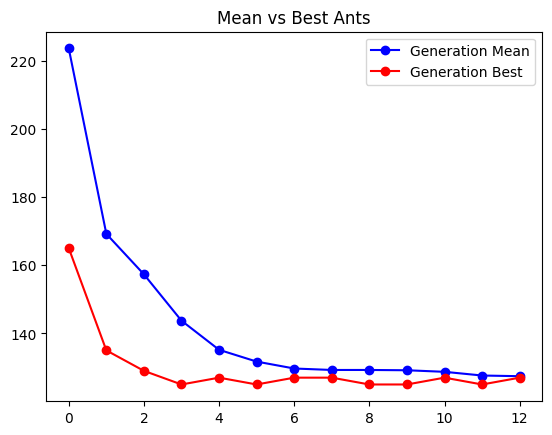

-----------Generation 0------------
NEW BEST: 7271
NEW BEST: 1561
NEW BEST: 1235
NEW BEST: 815
MEAN: 5475.158730158731
-----------Generation 1------------
MEAN: 4836.419354838709
-----------Generation 2------------
NEW BEST: 681
MEAN: 4721.8421052631575
-----------Generation 3------------
MEAN: 4047.4444444444443
-----------Generation 4------------
MEAN: 3747.6666666666665
-----------Generation 5------------
MEAN: 2610.5
-----------Generation 6------------
MEAN: 2552.75
-----------Generation 7------------
MEAN: 1751.0
-----------Generation 8------------
MEAN: 3410.0
-----------Generation 9------------
MEAN: 3866.6
-----------Generation 10------------
MEAN: 2447.0
-----------Generation 11------------
MEAN: 3193.0
-----------Generation 12------------
Stopped early due to no increase
Time taken: 39.116
Route size: 681
Ants that got out: 16.373626373626372%


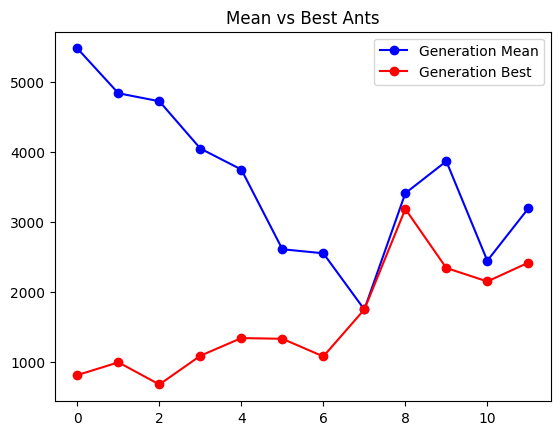

In [24]:
# Please keep your parameters for the ACO easily changeable here
gen = 70 # ants per generation
no_gen = 25 # nr of generations
q = 5000
evap = 0.25
step_scale_factor = 200
pheromone_exp = 4
heuristic_exp = 1
patience = 10
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco_remove_loops = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)
aco_nothing = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp, remove_loops = False)

test_hyperparams(aco_remove_loops, "medium")
test_hyperparams(aco_nothing, "medium")

### 2.5 Parameter Optimization

#### Question 16

#### The easy maze

#### Parameter tuning
- **gen = 150**: This is probably too high for a maze of such reduced complexity, but we will stick with this number for safety, as the time needed to run is still very low.
- **no_gen = 50**: This is more than enough for the algorithm to converge, as seen in the plot.
- **q = 1000**: This value for q has been chosen keeping in mind the length of a route in this maze. If an ant finds a route of length 50, the pheromone on each tile will be 1000/50 = 20, a reasonable amount compared to the initial value of a tile.
- **evap = 0.2**: We found evaporation of 0.2 works best. This means the ants will not be following a suboptimal path for too long, as it will be erased.
- **step_scale_factor = 10**: This is irrelevant for this maze, as all ants exit in a very short period of time.
- **pheromone_exp = 3 & heuristic_exp = 2**: This ensures that the ants, while prioritizing following each other's trails, will keep exploring.
- **patience = 10 & threshold = 0**: This accounts for any slight change in the optimal route, making the ants follow the best path to the exit by taking as many generations as they need.
#### Impact on performance
For this maze, which is pretty small, we can afford to do slightly more computations than for the more complicated ones. We can see the convergence starts around the sixth generation. For this specific example, we can even look at the maze and notice the optimal solution can be found by only doing right and down moves (since we need to get from one corner to the opposite one). Therefore, the algorithm finds the optimal route (of length 38), after which all further generations will follow the optimal found route. This can be seen by the blue line (the mean of the swarm) chasing the red line, showing how the group slowly discovers the best route by following the best ants.

Ready reading maze file ./../data/easy_maze.txt
-----------Generation 0------------
NEW BEST: 70
NEW BEST: 50
NEW BEST: 44
MEAN: 71.06666666666666
-----------Generation 1------------
NEW BEST: 38
MEAN: 57.626666666666665
-----------Generation 2------------
MEAN: 52.50666666666667
-----------Generation 3------------
MEAN: 51.13333333333333
-----------Generation 4------------
MEAN: 47.78666666666667
-----------Generation 5------------
MEAN: 45.026666666666664
-----------Generation 6------------
MEAN: 45.2
-----------Generation 7------------
MEAN: 43.77333333333333
-----------Generation 8------------
MEAN: 44.04
-----------Generation 9------------
MEAN: 43.093333333333334
-----------Generation 10------------
MEAN: 41.93333333333333
-----------Generation 11------------
MEAN: 42.38666666666666
-----------Generation 12------------
MEAN: 43.626666666666665
-----------Generation 13------------
MEAN: 42.4
-----------Generation 14------------
MEAN: 42.906666666666666
-----------Generation 15----

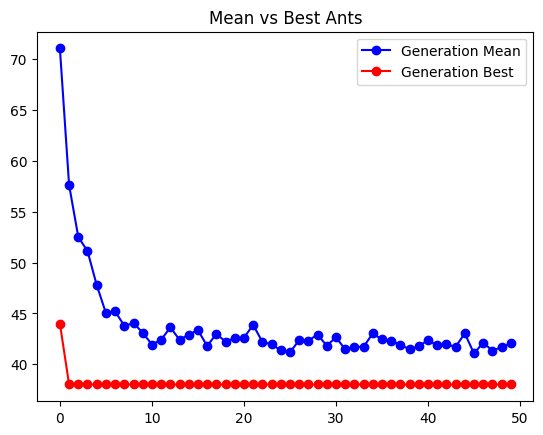

In [25]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 50 # nr of generations
q = 1000
evap = 0.2
step_scale_factor = 10
pheromone_exp = 3
heuristic_exp = 2
init_pheromones = 0.5
patience = 50
threshold = 0

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "easy")

### The medium maze

 #### Parameter Tuning
 - **gen = 150**: The number of ants per generation is enough for this maze. It is large enough so that we have a sample we can work with, while also not taking very long time-wise.
 - **no_gen = 25**: By trial and error, we noticed that the ants usually converge by generation 10 to 15, so we figured we would give a safe margin of 10 generations.
 - **q = 20000**: We expect routes of around 150-200, in which case a tile would have around 20000/200 = 100 pheromones. Considering the relatively reduced complexity of the maze, we can say that a found path is likely decent, having few loops/open areas. Therefore, using a large value for q will guide the colony faster towards the exit, having a direct impact on the speed of convergence.
  - **evap = 0.25**: After we set the q to a higher value, we must also think about evaporating the path faster in case it truly is bad. Therefore, we will use slightly higher evaporation for this maze.
  - **pheromone_exp = 4 & heuristic_exp = 1**: To further support the swarm idea above, we set the pheromone exponent to a high value, as we want the group to follow the best paths and reduce exploration. Heuristic exponent is set to one, forming a good ratio between the two.
   - **patience = 10 & threshold = 0**: We want to account for every slight change in the maze, which is why we give them enough time to find the optimal route.
   - **step_scale_factor = 200**: This is rarely enforced in this run, as the ants will almost always find the exit. We can see this from the high percentage that made it out. However, it is still a good limit to have if some are stuck in loops.
   #### Impact on Performance
   We still have a very high percentage of ants still making it out of the maze, [[percentage]]. The speed of convergence is quite high for this maze as well, needing around four or five generations to get closer to the optimal route. As above, we see the blue line following the red one, as by the end the mean of the 150 ants from the final generation is just six above the best route found.

Ready reading maze file ./../data/medium_maze.txt
-----------Generation 0------------
NEW BEST: 207
NEW BEST: 171
NEW BEST: 165
NEW BEST: 151
MEAN: 221.15151515151516
-----------Generation 1------------
NEW BEST: 145
NEW BEST: 141
NEW BEST: 139
NEW BEST: 137
MEAN: 166.94444444444446
-----------Generation 2------------
NEW BEST: 131
NEW BEST: 129
MEAN: 152.13333333333333
-----------Generation 3------------
NEW BEST: 127
MEAN: 139.38666666666666
-----------Generation 4------------
MEAN: 134.66666666666666
-----------Generation 5------------
MEAN: 131.72
-----------Generation 6------------
NEW BEST: 125
MEAN: 130.18666666666667
-----------Generation 7------------
MEAN: 129.58666666666667
-----------Generation 8------------
MEAN: 129.06666666666666
-----------Generation 9------------
MEAN: 129.13422818791946
-----------Generation 10------------
MEAN: 128.96
-----------Generation 11------------
MEAN: 128.61333333333334
-----------Generation 12------------
MEAN: 128.37333333333333
----------

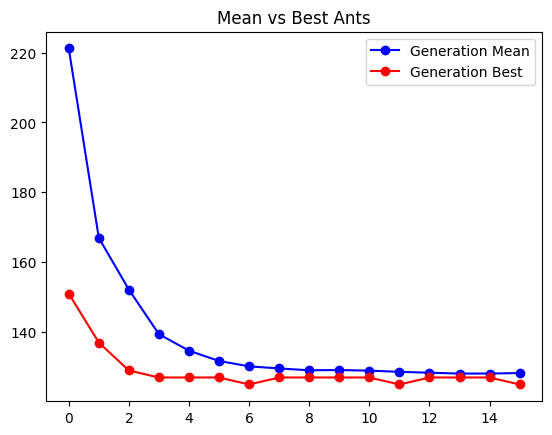

In [26]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 25 # nr of generations
q = 20000
evap = 0.25
step_scale_factor = 200
pheromone_exp = 4
heuristic_exp = 1
patience = 10
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "medium")

### The hard maze

#### Parameter Tuning
- **gen = 150**: 150 is large enough, even for a maze of this scale. By lowering it, we would be much more susceptible to randomness, especially when plotting the mean, as one outlier ant could have a much longer route and impact the whole mean of a generation. Therefore, we need to make use of as many ants as we can while also keeping the computational time in mind.
- **no_gen = 50**: we found empirically that we would need 30 to 40 generations to get the mean around 800, and therefore we have taken the maximum to be slightly above that, at 50.
- **q = 22,000**: We figured that we did not want any single loop to have a lot of pheromones on it. We need to facilitate exploration, which is why the q value has increased only slightly as compared to the medium maze. What we want to keep in mind is the ratio between the average route length and the value of q. For a route of length, say, 1000, the pheromone on a tile would be q/l = 22000/1000 = 22. Therefore, even though the q value seems similar to the one used for the medium maze, its effect on the tiles will be different as a result of the increased complexity of the hard one. This quantity is enough for an ant to distinguish between a path with pheromone and a path which hasn't been visited by now, for example, but still low enough such that the ants do not blindly follow the same route too many times.
- **evap = 0.3**: We increased the evaporation slightly, such that the ants will always continue to search for better paths and not converge too early on a suboptimal one.
- **pheromone_exp = 3.5 & heuristic_exp = 1.3**: We have slightly increased exploration (by reducing the exploitation factor pheromone_exp and increasing the exploration factor heuristic_exp). This was done because there are many loops and open spaces, and we wish to avoid them as much as possible. Note we would not like to increase the heuristic_exp to be greater than pheromone_exp, because the whole idea of the ants is that they follow pheromone. If we were to do that, they would simply be avoiding their own found routes.
- **step_scale_factor = 5**: This low value was chosen only to save computational time, and it is to be expected that the number of ants that get out will be greatly reduced. To improve this, we could just raise the step_scale_factor at the cost of time.
- **patience = 15 & threshold = 0**: We are tuning these values so that if we see even the slightest change during 15 generations, it means the path has not converged yet. This is because ants can always find a better path, even when it seems they have already converged. We need to give them the appropriate time to explore the maze fully.
#### Impact on Performance
For this maze, and as expected, it takes a little more time to converge. As before, we initially see a big drop in the mean line, but it keeps following a downstream trend until it eventually reaches a mean of length about 15 higher than the best route found. This is also pretty good, considering we are talking about routes of length 780 to 800, considerably larger than 38 or 130 from the previous mazes.

Ready reading maze file ./../data/hard_maze.txt
-----------Generation 0------------
NEW BEST: 975
NEW BEST: 947
NEW BEST: 937
NEW BEST: 901
NEW BEST: 865
MEAN: 982.0769230769231
-----------Generation 1------------
NEW BEST: 861
NEW BEST: 839
NEW BEST: 837
NEW BEST: 817
NEW BEST: 815
MEAN: 896.6129032258065
-----------Generation 2------------
NEW BEST: 813
MEAN: 846.0930232558139
-----------Generation 3------------
NEW BEST: 797
MEAN: 833.5333333333333
-----------Generation 4------------
MEAN: 831.6206896551724
-----------Generation 5------------
MEAN: 819.6511627906976
-----------Generation 6------------
MEAN: 820.7746478873239
-----------Generation 7------------
MEAN: 818.9777777777778
-----------Generation 8------------
MEAN: 819.1395348837209
-----------Generation 9------------
MEAN: 815.6813186813187
-----------Generation 10------------
MEAN: 816.775
-----------Generation 11------------
MEAN: 812.8518518518518
-----------Generation 12------------
MEAN: 813.1176470588235
-----------

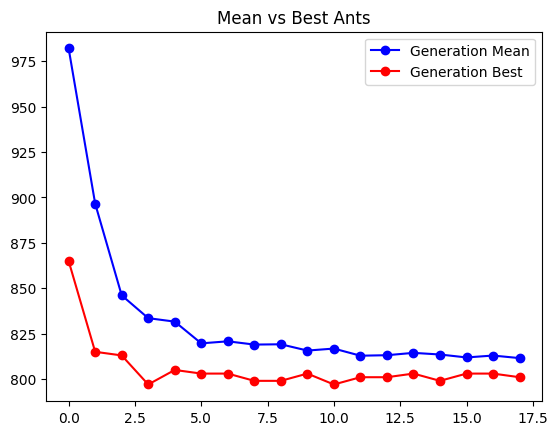

In [27]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 50 # nr of generations
q = 22000
evap = 0.3
step_scale_factor = 5
pheromone_exp = 3.5
heuristic_exp = 1.3
patience = 15
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/hard_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/hard_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "hard")

 <div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 17

_Using your answer to the previous question, how does the complexity and size of a
maze influence the “optimal” value of each hyper-parameter?_

The choice of parameters highly depends on the maze, but some are also co-dependent. For example, the value for q should be set keeping in mind the average route an ant should make in a maze. However, choosing a higher value for q also implies choosing a higher value for the evaporation factor, otherwise ants will just blindly follow the same potentially bad route over and over again.
Patience and threshold should be set empirically, based on how fast the plot converges, but also on the speed of computation, which comes directly from the maze complexity. The number of ants in a generation should always be as high as possible, as we want to make the most out of every generation. More ants per generation means we rely less and less on luck, and we slowly approach the true performance of our algorithm. Of course, we can afford to use fewer ants on a less complex maze, but it becomes a must when it comes to mazes such as the hard one. The pheromone exponent reflects how much the ants follow each other. Therefore, when a maze has few loops or few dead ends, we would like ants to follow each other as much as possible. As seen in the hard maze, though, when we have many choices to make and exploration is required to efficiently exit the maze, we should decrease it a bit to let the ants look for every possible way of getting out. Heuristic_exp was, in our case, always set to 1 except for the easy maze. That is because generally, we ultimately still want the ants to follow their tracks, and it is easier to adjust one exponent out of the 2 while keeping the other constant.

### 2.6 The Final Route

#### Question 18

### Easy Final Route

In [28]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 50 # nr of generations
q = 1000
evap = 0.2
step_scale_factor = 10
pheromone_exp = 3
heuristic_exp = 2
init_pheromones = 0.5
patience = 50
threshold = 0

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "easy", show_plot=False)

Ready reading maze file ./../data/easy_maze.txt
-----------Generation 0------------
NEW BEST: 62
NEW BEST: 44
NEW BEST: 38
MEAN: 73.65333333333334
-----------Generation 1------------
MEAN: 61.84
-----------Generation 2------------
MEAN: 54.89333333333333
-----------Generation 3------------
MEAN: 53.04
-----------Generation 4------------
MEAN: 51.24
-----------Generation 5------------
MEAN: 50.56
-----------Generation 6------------
MEAN: 49.53333333333333
-----------Generation 7------------
MEAN: 49.18666666666667
-----------Generation 8------------
MEAN: 49.013333333333335
-----------Generation 9------------
MEAN: 49.053333333333335
-----------Generation 10------------
MEAN: 48.053333333333335
-----------Generation 11------------
MEAN: 48.906666666666666
-----------Generation 12------------
MEAN: 48.68
-----------Generation 13------------
MEAN: 48.54666666666667
-----------Generation 14------------
MEAN: 48.88
-----------Generation 15------------
MEAN: 47.48
-----------Generation 16---

#### Medium Final Route

Ready reading maze file ./../data/medium_maze.txt
-----------Generation 0------------
NEW BEST: 205
NEW BEST: 175
NEW BEST: 171
NEW BEST: 161
NEW BEST: 157
MEAN: 222.75757575757575
-----------Generation 1------------
NEW BEST: 155
NEW BEST: 147
NEW BEST: 139
NEW BEST: 137
MEAN: 176.44
-----------Generation 2------------
NEW BEST: 129
MEAN: 159.20833333333334
-----------Generation 3------------
MEAN: 153.93959731543623
-----------Generation 4------------
MEAN: 148.7718120805369
-----------Generation 5------------
MEAN: 148.0
-----------Generation 6------------
NEW BEST: 127
MEAN: 147.36
-----------Generation 7------------
MEAN: 147.16
-----------Generation 8------------
MEAN: 147.28
-----------Generation 9------------
MEAN: 145.92
-----------Generation 10------------
MEAN: 146.17333333333335
-----------Generation 11------------
MEAN: 146.86577181208054
-----------Generation 12------------
MEAN: 146.38666666666666
-----------Generation 13------------
MEAN: 145.70666666666668
-----------G

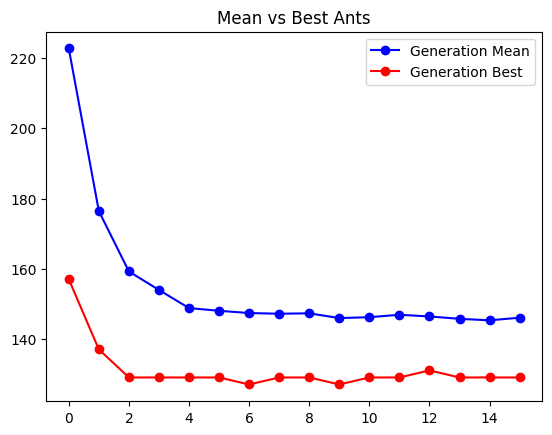

In [29]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 25 # nr of generations
q = 20000
evap = 0.25
step_scale_factor = 200
pheromone_exp = 4
heuristic_exp = 1
patience = 10
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/medium_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/medium_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "medium")

### Hard Final Route

Ready reading maze file ./../data/hard_maze.txt
-----------Generation 0------------
NEW BEST: 933
NEW BEST: 909
MEAN: 969.75
-----------Generation 1------------
NEW BEST: 883
NEW BEST: 881
NEW BEST: 841
MEAN: 895.0677966101695
-----------Generation 2------------
NEW BEST: 839
NEW BEST: 831
NEW BEST: 821
NEW BEST: 807
MEAN: 857.9722222222222
-----------Generation 3------------
NEW BEST: 803
MEAN: 845.0
-----------Generation 4------------
MEAN: 843.5205479452055
-----------Generation 5------------
NEW BEST: 797
MEAN: 837.3478260869565
-----------Generation 6------------
MEAN: 834.4473684210526
-----------Generation 7------------
MEAN: 831.9041095890411
-----------Generation 8------------
MEAN: 826.3731343283582
-----------Generation 9------------
MEAN: 824.5
-----------Generation 10------------
MEAN: 823.8
-----------Generation 11------------
MEAN: 819.2777777777778
-----------Generation 12------------
NEW BEST: 793
MEAN: 822.2266666666667
-----------Generation 13------------
MEAN: 818.9

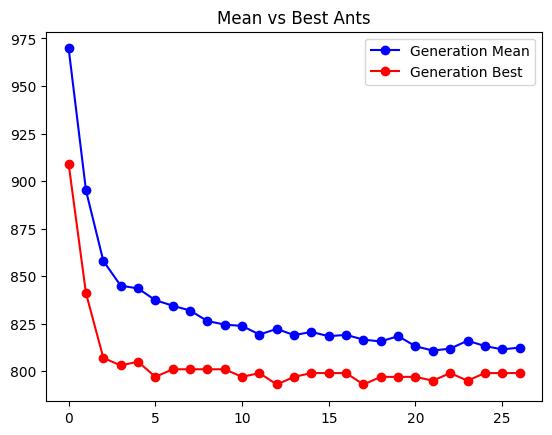

In [30]:
# Please keep your parameters for the ACO easily changeable here
gen = 150 # ants per generation
no_gen = 50 # nr of generations
q = 22000
evap = 0.3
step_scale_factor = 5
pheromone_exp = 3.5
heuristic_exp = 1.3
patience = 15
threshold = 0
init_pheromones = 0.001

# Construct the optimization objects
maze = Maze.create_maze("./../data/hard_maze.txt", init_pheromones)
spec = PathSpecification.read_coordinates("./../data/hard_coordinates.txt")

max_steps = maze.width * maze.length * step_scale_factor

aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

test_hyperparams(aco, "hard")

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.7 Synthesis

#### Question 19

In [35]:
  # Please keep your parameters for the ACO easily changeable here
gen = 5 # ants per generation
no_gen = 7 # nr of generations
q = 22000
evap = 0.3
step_scale_factor = 5
pheromone_exp = 3.5
heuristic_exp = 1.3
patience = 15
threshold = 0
init_pheromones = 0.001

generations = 200
population_size = 4000

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt", init_ph = 0.01)
max_steps = maze.width * maze.length * step_scale_factor
spec = PathSpecification.read_coordinates(coordinates)
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = IntelligentAntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, patience, threshold, pheromone_exp, heuristic_exp)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(200, 4000)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

Ready reading maze file ./../data/hard_maze.txt
-----------Generation 0------------
NEW BEST: 0
MEAN: 0.0
-----------Generation 1------------
MEAN: 0.0
-----------Generation 2------------
MEAN: 0.0
-----------Generation 3------------
MEAN: 0.0
-----------Generation 4------------
MEAN: 0.0
-----------Generation 5------------
MEAN: 0.0
-----------Generation 6------------
MEAN: 0.0
-----------Generation 0------------
NEW BEST: 83
NEW BEST: 75
NEW BEST: 73
MEAN: 88.6
-----------Generation 1------------
MEAN: 76.6
-----------Generation 2------------
MEAN: 79.0
-----------Generation 3------------
MEAN: 77.0
-----------Generation 4------------
MEAN: 76.6
-----------Generation 5------------
MEAN: 77.4
-----------Generation 6------------
MEAN: 77.4
-----------Generation 0------------
-----------Generation 1------------
-----------Generation 2------------
NEW BEST: 936
MEAN: 936.0
-----------Generation 3------------
NEW BEST: 890
MEAN: 890.0
-----------Generation 4------------
MEAN: 892.0
------

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

In [34]:
ga = GeneticAlgorithm(2000, 2000)
solution = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

_Genetic algorithms need a fitness function but there are many scenarios where you
will not know the correct (underlying) fitness function. Discuss an example where this
would be the case. How can it cause problems?_

In the artistic field, there is no formula to determine the fitness of an individual chromosome. For example, if a producer wants to evolve music, there can't be a correct track, since preferences are subjective - there is no mathematic formula to determine if a song became better or not. One resulting problem of not having a fitness function, in this situation is that the producer would have to manually give a score to each new evolution. Because this process is not automated anymore, it would take much more time, and it would also be unreliable, because, again, this is a subjective matter.

#### Question 21

_What about “survival functions”? Do we always want the strongest individual to survive? How can we mitigate these problems through the mechanisms of selection?_

We do not want to always use survival functions. If we apply them, the population will converge prematurely, elements becoming more and more similar, and all genetic variation would disappear. This can also induce a local best result, but which is totally different from the optimal one. To mitigate these problems, we can perform tournament selection, where we pick a small subset of elements, and pick the best one out of those. This way, we still rely on randomness, thus, we are not guaranteed that the strongest individual is also saved. This helps to create more variety.

### 3.2 Pen and Paper

#### Question 22

_Imagine that our robot attempts to select the best set of foods based on their price and
nutritional value (see the plot above). Which of the variables do you think we should
maximize or minimize? What are the Pareto frontiers? If the robot can carry only four
products, which of them will it choose according to the NDSGA-II algorithm? Justify
all of your answers._

The answer to this question is provided in the attached PDF.

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**